### E-Commerce Business Analysis

In [1]:
# Library
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
import seaborn as sn
import plotly.express as px
import kagglehub
import seaborn as sns
print("listo librerias")

listo librerias


d:\Josefina\Proyectos\Datascience\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#Extrar desde kaggle: https://www.kaggle.com/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr
import kagglehub

# Download latest version
path = kagglehub.dataset_download("umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Josefina Urquiza\.cache\kagglehub\datasets\umuttuygurr\e-commerce-customer-behavior-and-sales-analysis-tr\versions\2


In [2]:
# El link se saca de lo que me dice kaggle antes
df = pd.read_csv("C:/Users/Josefina Urquiza/.cache/kagglehub/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr/versions/2/ecommerce_customer_behavior_dataset_v2.csv")

df

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17044,ORD_004999-1,CUST_04999,2024-01-16,44,Male,Antalya,Beauty,68.65,2,0.00,137.30,Digital Wallet,Mobile,14,10,False,6,1
17045,ORD_005000-1,CUST_05000,2023-02-22,24,Female,Eskisehir,Beauty,156.12,1,0.00,156.12,Credit Card,Mobile,15,8,True,7,5
17046,ORD_005000-2,CUST_05000,2023-06-29,24,Female,Eskisehir,Home & Garden,1065.24,3,0.00,3195.72,Credit Card,Desktop,17,11,True,5,4
17047,ORD_005000-3,CUST_05000,2023-12-29,24,Female,Eskisehir,Books,47.73,2,8.80,86.66,Credit Card,Desktop,13,11,True,12,2


In [10]:
# Configuracion SQL
%load_ext sql

print("Configuracion y librerias OK")

The sql extension is already loaded. To reload it, use:
  %reload_ext sql
Configuracion y librerias OK


In [11]:
# Usar un archivo como SQLite como base de datos
database_filename = 'ecommerce_customer_behavior.db'
df.to_sql('ecommerce_customer_behavior', f'sqlite:///{database_filename}', if_exists='replace', index=False)

# Conexion a la base de datos generada
%sql sqlite:///ecommerce_customer_behavior.db

#Configuracion de sql (revisar)
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

In [12]:
# Primera consulta, mostrar la data y ver si funciona el sql
%sql SELECT * FROM ecommerce_customer_behavior LIMIT 10;

 * sqlite:///ecommerce_customer_behavior.db
   sqlite:///ecommerce_sales_data.db
Done.


Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.0,29.18,Digital Wallet,Mobile,14,9,1,13,4
ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.4,1,138.05,506.35,Credit Card,Desktop,14,8,1,6,2
ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.0,1664.1,Credit Card,Mobile,15,10,1,9,4
ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.3,5,71.05,275.45,Digital Wallet,Desktop,16,13,1,4,4
ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.0,534.45,Credit Card,Mobile,14,7,1,6,4
ORD_000003-1,CUST_00003,2023-02-27,42,Male,Konya,Toys,198.28,2,0.0,396.56,Credit Card,Tablet,10,9,0,6,2
ORD_000003-2,CUST_00003,2024-01-03,42,Male,Konya,Home & Garden,526.85,5,0.0,2634.25,Digital Wallet,Desktop,11,8,1,6,5
ORD_000004-1,CUST_00004,2024-02-13,53,Male,Izmir,Fashion,96.2,5,97.78,383.22,Credit Card,Desktop,16,15,0,4,5
ORD_000005-1,CUST_00005,2023-03-16,32,Male,Ankara,Home & Garden,533.67,3,0.0,1601.01,Bank Transfer,Mobile,12,8,0,5,5
ORD_000005-2,CUST_00005,2023-06-12,32,Male,Ankara,Toys,73.06,4,0.0,292.24,Credit Card,Mobile,13,12,1,7,2


####  01. Analisis exploratorio general del dataset
Primero es necesario entender bien el dataset.

In [ ]:
# Algunas metricas estadisticas basicas y de exploracion general del dataset()
print(df.info())
#No hay nulos ni duplicados
# df.isnull().sum()
# df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  str    
 1   Customer_ID               17049 non-null  str    
 2   Date                      17049 non-null  str    
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  str    
 5   City                      17049 non-null  str    
 6   Product_Category          17049 non-null  str    
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  str    
 12  Device_Type               17049 non-null  str    
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_Viewed     

In [17]:
print(df.describe())


                Age    Unit_Price      Quantity  Discount_Amount  \
count  17049.000000  17049.000000  17049.000000     17049.000000   
mean      34.945745    447.901689      3.011379        69.788135   
std       11.046855    722.319705      1.417027       240.704662   
min       18.000000      5.050000      1.000000         0.000000   
25%       26.000000     73.260000      2.000000         0.000000   
50%       35.000000    174.680000      3.000000         0.000000   
75%       42.000000    494.570000      4.000000        32.710000   
max       75.000000   7900.010000      5.000000      6538.290000   

       Total_Amount  Session_Duration_Minutes  Pages_Viewed  \
count  17049.000000              17049.000000  17049.000000   
mean    1277.438711                 14.535633      9.003109   
std     2358.436375                  2.925524      2.259954   
min        6.210000                  4.000000      1.000000   
25%      172.970000                 13.000000      7.000000   
50%      

In [ ]:
#Configurar la fecha
df["Date"] = pd.to_datetime(df["Date"])
df

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17044,ORD_004999-1,CUST_04999,2024-01-16,44,Male,Antalya,Beauty,68.65,2,0.00,137.30,Digital Wallet,Mobile,14,10,False,6,1
17045,ORD_005000-1,CUST_05000,2023-02-22,24,Female,Eskisehir,Beauty,156.12,1,0.00,156.12,Credit Card,Mobile,15,8,True,7,5
17046,ORD_005000-2,CUST_05000,2023-06-29,24,Female,Eskisehir,Home & Garden,1065.24,3,0.00,3195.72,Credit Card,Desktop,17,11,True,5,4
17047,ORD_005000-3,CUST_05000,2023-12-29,24,Female,Eskisehir,Books,47.73,2,8.80,86.66,Credit Card,Desktop,13,11,True,12,2


Desglose del dataset

Las variables se pueden dividir en 4 bloques:

1.	Perfil del cliente:
   - Age
   - Gender
   - City
2.	Comportamiento de compra
   - Product_Category
   - Unit_Price
   - Quantity
   - Discount_Amount
   - Total_Amount
3.	Comportamiento digital
   - Device_Type
   - Session_Duration
   - Pages_Viewed
4.	Experiencia post-compra
   - Delivery_Time
   - Customer_Rating
   - Is_Returning_Customer


Analisis 1° bloque: 

1.	Perfil del cliente:
   - Age
   - Gender
   - City

### Variable: AGE
¿Qué queremos entender?
- Distribución de edades
- Si hay concentración en algún rango
- Si el negocio está orientado a un público joven, adulto, etc

count    17049.000000
mean        34.945745
std         11.046855
min         18.000000
25%         26.000000
50%         35.000000
75%         42.000000
max         75.000000
Name: Age, dtype: float64


<Axes: title={'center': 'Distribución de Edad'}, xlabel='Age_Group', ylabel='Count'>

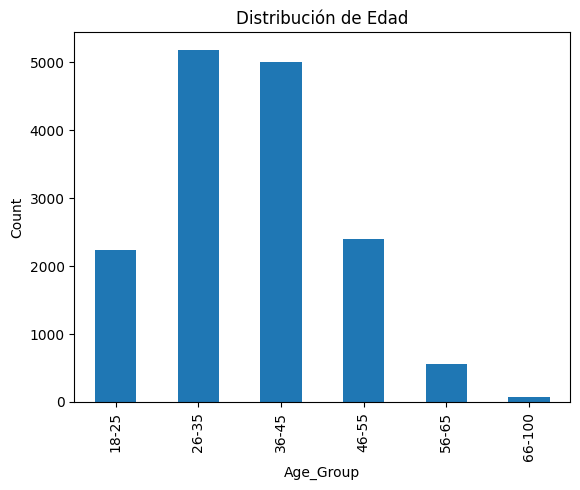

In [10]:
# Estadísticos básicos
print(df["Age"].describe())
#Plot de distribucion
sns.histplot(df["Age"], bins=20)
plt.title("Distribución de Edad")

##################################
#Plot de distribucion por bins
bins = [18, 25, 35, 45, 55, 65,100]
labels = ["18-25","26-35","36-45","46-55","56-65", "66-100"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

df["Age_Group"].value_counts().sort_index().plot(kind="bar")


Resumen
- La edad minima es de 18 años (solo mayores de edad)
- La mayor proporcion esta entre 26-45 años, es decir un publico joven-adulto
- Poblacion economicamente activa
- Media vs Mediana: la distribucion es bastante simetrica y no presenta sesgos fuertes
- El max de edad que compro fue de 72
- Es un e-commerce de aultos jovenes con cierto poder adquisitivo 

### Variable: GENDER 
¿Qué queremos entender?
- Es variable categórica.
- Proporción hombres vs mujeres
- Si está balanceado el público

Gender
Female    0.505191
Male      0.479559
Other     0.015250
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Distribución por Género')

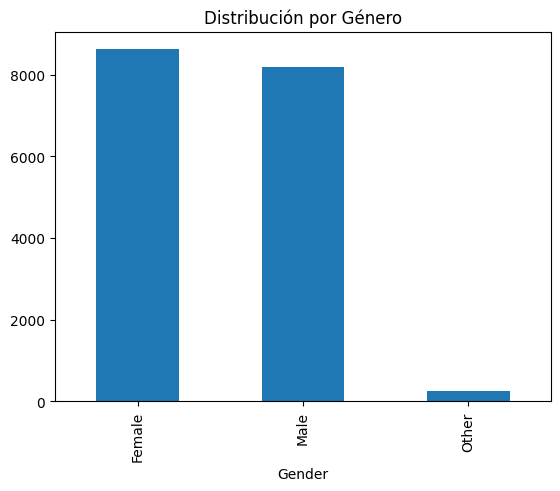

In [12]:
#Contamos cuantos hay de cada genero
print(df["Gender"].value_counts(normalize=True))
#Plot
df["Gender"].value_counts().plot(kind="bar")
plt.title("Distribución por Género")

Resumen:
- Distribución  equilibrada.
- No es un e-commerce claramente orientado a un solo género.
- Permite estrategias de segmentación más fina
- El grupo Other (1.5%) es pequeño pero existe. Podria ser importante desde el punto de vista de inclusión y segmentación futura.

##### Variable: city 
Qué queremos entender?
- Está concentrado en pocas ciudades?
- Es un negocio nacional o concentrado



City
Istanbul     4402
Ankara       2422
Izmir        2072
Bursa        1721
Adana        1326
Antalya      1246
Gaziantep    1183
Konya        1120
Kayseri       851
Eskisehir     706
Name: count, dtype: int64
Valor:  0.5217901343187284


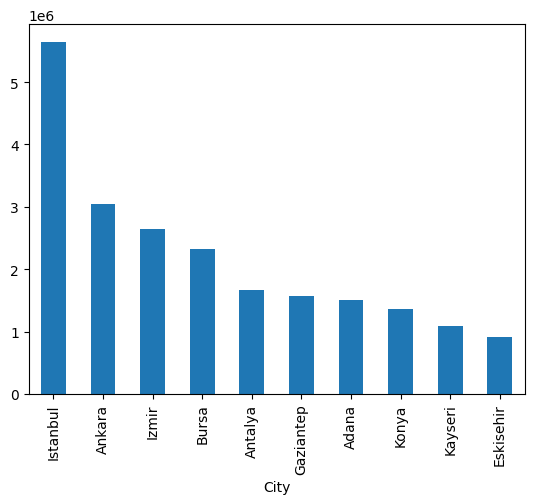

In [21]:
# En cuantas ciudades esta el negocio, llega el negocio o son los clientes
print(df["City"].value_counts())
####
# Plot 1
#df["City"].value_counts().plot(kind="bar")
#plt.title("Top 10 ciudades por cantidad de órdenes")
#Plot 2
df.groupby("City")["Total_Amount"].sum().sort_values(ascending=False).plot(kind="bar")

top3 = df["City"].value_counts(normalize=True).head(3).sum()
print("Valor: ",top3)

- El negocio ocurre en distintas ciudades de Turquia
- Esto corresponde a cantidad de compras
- Estanbul corresponde al 26% de las compras
- Hay 3 ciudades que dominnan y el resto de menor participacion


## Analisis exploratorio del 2° Bloque: Comportamiento de compra
   - Product_Category
   - Unit_Price
   - Quantity
   - Discount_Amount
   - Total_Amount

##### Variable: Product_Category (categórica)
Qué queremos entender?
- Cantidad de órdenes por categoría
- Proporción sobre el total
- Distribución (¿está concentrado o equilibrado?)

Product_Category
Sports           2248
Beauty           2212
Books            2206
Food             2103
Toys             2090
Electronics      2074
Home & Garden    2060
Fashion          2056
Name: count, dtype: int64


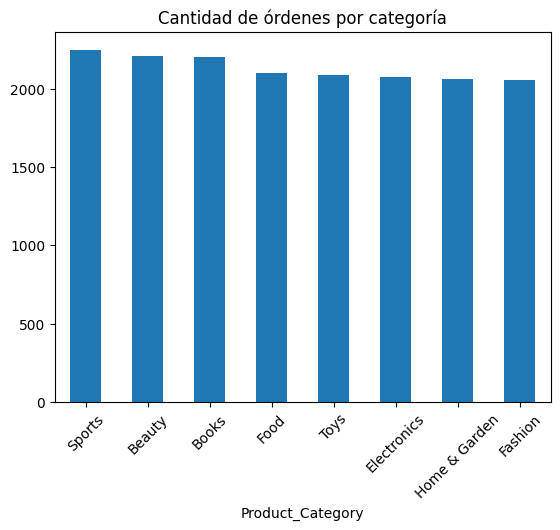

In [25]:
# Cantidad
print(df["Product_Category"].value_counts())
df["Product_Category"].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Cantidad de órdenes por categoría")
plt.xticks(rotation=45)
plt.show()

- La distribucion de compra de las categorias son bastante homogeneas entre 12-13% cada uno. Un poco mas sports pero no hay diferencias significativas.
- Son 8 las categorias que hay: Sports; Beauty; Books; Food; Toys; Electronics; Home & Garden; Fashion.

In [ ]:
total = 17049 
Sports =         (2248 / total)*100
Beauty  =        ( 2212/ total)*100
Books    =       ( 2206/ total)*100
Food      =      ( 2103/ total)*100
Toys       =     ( 2090/ total)*100
Electronics =    ( 2074 / total)*100
Home =    ( 2060/ total)*100
Fashion =   (  2056/ total)*100

print(Sports)
print(Beauty)
print(Books)
print(Food)
print(Toys)
print(Electronics)
print(Home)
print(Fashion)


13.185524077658513
12.974367998123057
12.93917531820048
12.335034312862925
12.25878350636401
12.164936359903807
12.082820106751129
12.059358320136077


96

##### Variable: Unit_Price (precio unitario)
- Que ver como es el precio de las categorias

count    17049.000000
mean       447.901689
std        722.319705
min          5.050000
25%         73.260000
50%        174.680000
75%        494.570000
max       7900.010000
Name: Unit_Price, dtype: float64


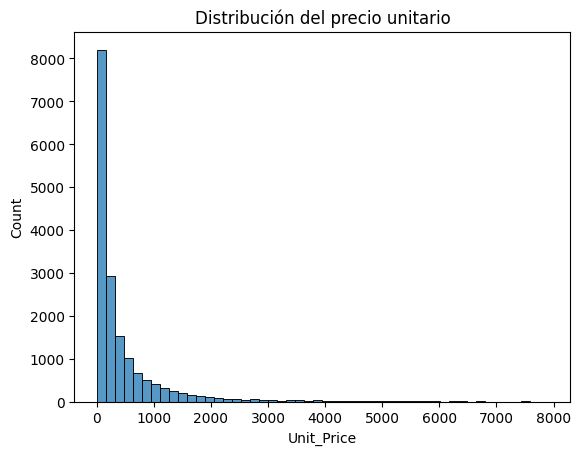

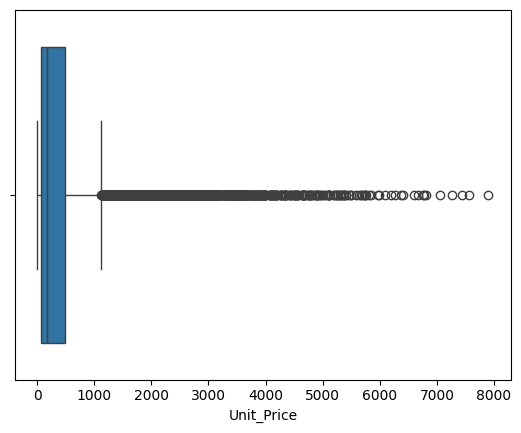

In [31]:
#Estadistica basica
print(df["Unit_Price"].describe())

#Distribucion de los precios
sns.histplot(df["Unit_Price"], bins=50)
plt.title("Distribución del precio unitario")
plt.show()

# Para ver outliers
sns.boxplot(x=df["Unit_Price"])
plt.show()

##### Variable: Quantity (cantidad comprada)
- Que ver como es el precio de las categorias
- ¿Predomina comprar 1 unidad?
- ¿Está equilibrado?
- ¿Hay sesgo hacia compras pequeñas?

count    17049.000000
mean         3.011379
std          1.417027
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Quantity, dtype: float64


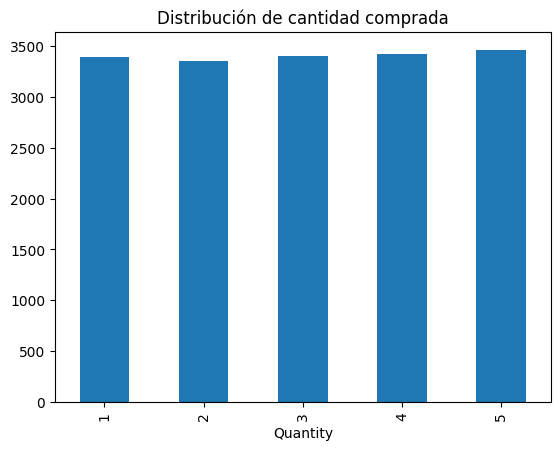

In [32]:
#Estadistica basica
print(df["Quantity"].describe())
#Plot de cantidad
df["Quantity"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de cantidad comprada")
plt.show()

- El valor va de 1 - 5
- Es uniforme la distibucion de la cantidad de compra no hay diferencias notables
- No hay un sesgo hacia compras mas pqueñas o mas altas es uniforme el patron de compra

##### Variable: Discount_Amount (descuento)


count    17049.000000
mean        69.788135
std        240.704662
min          0.000000
25%          0.000000
50%          0.000000
75%         32.710000
max       6538.290000
Name: Discount_Amount, dtype: float64


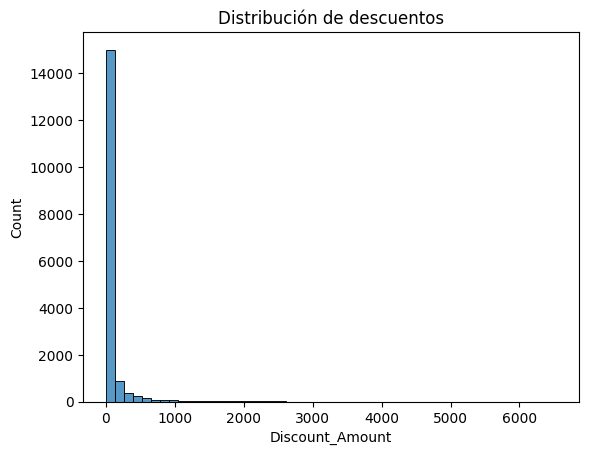

In [34]:
#Estadistica basica
print(df["Discount_Amount"].describe())
#Como se distribuyen los descuetnsos
sns.histplot(df["Discount_Amount"], bins=50)
plt.title("Distribución de descuentos")
plt.show()

Resumen
- 50% no tiene descuento
- Cuando hay descuento, puede ser muy alto

Algunas consideraciones:
- Edad: vemos un público bastante joven-adulto. Lo que podría implicar, uso alto del celular y un buen potencial de recompra digital.
- Unit_Price: La dispersion es alta y fuerte asimetría positiva. Hay productos muy caros que elevan la media. Esto puede deberse que el revenue puede estar concentrado en pocos productos. Es necesirio analizar distribución por categoría.
- Discount_Amount: El 50% de las compras NO tiene descuento. Pero en el resto los descuentos son altos hay descuentos enormes.
- Total_Amount: alta asimetría, lo que refuerza que hay compras muy grandes que cambian la media.
- Session Duration: Media: 14.5 minutos con un rango entre 4 y 26 min. Muy consistente. No parece haber valores raros.
- Pages Viewed: Media: 9 con un rango entre 1 y 18. Esto puede ser importante para la conversion o la recompra.
- Delivery Time: hay una media de 6.5 días y con un maximo de 25 dias, que es alto. Puede ser importante para la recompra
- Customer Rating: representa la calificación que el cliente le dio a su compra (1-5). Media: 3.9 / 5  Bastante bueno.